<a href="https://colab.research.google.com/github/unVeroz007/IP-Sems6/blob/main/Pertemuan5/Tugas_Pertemuan_5_IP_Muhammad_Galild_Avero_2311532008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library


In [37]:
from PIL import Image   # Library untuk membaca & menyimpan citra
import numpy as np      # Library untuk operasi array / matriks
import matplotlib.pyplot as plt        # untuk menampilkan banyak gambar

# 1. Membaca citra berwarna dan menampilkannya


In [38]:
# Membuka file gambar bernama 'spongebob.jpg'
img_color = Image.open("spongebob.jpg")

# Menampilkan informasi citra
print("   - Mode warna citra =", img_color.mode)
print("   - Ukuran citra (width x height) =", img_color.size)

   - Mode warna citra = RGB
   - Ukuran citra (width x height) = (300, 168)


# 2. Mengubah citra menjadi grayscale


In [39]:
# Menggunakan fungsi convert('L') untuk mengubah ke grayscale [web:15]
img_gray = img_color.convert("L")

# Menyimpan hasil citra grayscale
img_gray.save("01_citra_grayscale_spongebob.jpg")
print("Citra grayscale disimpan sebagai 01_citra_grayscale_spongebob.jpg\n")

Citra grayscale disimpan sebagai 01_citra_grayscale_spongebob.jpg



# 3. Mengubah citra grayscale menjadi array numpy

In [40]:
# Konversi citra (objek Image) menjadi array 2D (tipe uint8)
img_array = np.array(img_gray)
print("   - Tipe data array =", img_array.dtype)
print("   - Bentuk array (height, width) =", img_array.shape, "\n")

   - Tipe data array = uint8
   - Bentuk array (height, width) = (168, 300) 



# 4. Mendefinisikan kernel rataan 5x5


In [41]:
# Kernel rataan 5x5: semua elemen bernilai 1/25
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

print("   - Kernel 5x5:")
print(kernel)
print()

   - Kernel 5x5:
[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]



# 5. Melakukan padding pada citra


In [42]:
# Banyak padding di tiap sisi (karena kernel 5x5, radius = 2)
pad = kernel_size // 2    # 5 // 2 = 2

# Menambahkan padding 0 (hitam) di sekeliling citra
padded_img = np.pad(img_array, pad_width=pad, mode='constant', constant_values=0)

print("   - Bentuk citra setelah dipadding =", padded_img.shape)
print()

   - Bentuk citra setelah dipadding = (172, 304)



# 6. Melakukan operasi konvolusi secara manual


In [49]:
# Menyiapkan array output dengan ukuran yang sama dengan citra asli
height, width = img_array.shape
output = np.zeros((height, width), dtype=float)

# Dua loop untuk setiap posisi piksel (i, j)
for i in range(height):
    for j in range(width):
        # Mengambil patch 5x5 di sekitar piksel (i, j) dari citra yang sudah dipadding
        patch = padded_img[i:i+kernel_size, j:j+kernel_size]

        # Melakukan perkalian elemen-wise lalu dijumlahkan (dot product)
        value = np.sum(patch * kernel)

        # Menyimpan nilai hasil konvolusi pada posisi (i, j)
        output[i, j] = value

#7. Normalisasi Nilai Hasil

In [48]:
# Setelah konvolusi, nilai float perlu dipotong ke rentang 0-255,
# lalu dikonversi kembali ke uint8 agar bisa disimpan sebagai citra
output_clipped = np.clip(output, 0, 255).astype(np.uint8)

print("Konvolusi selesai.")
print("Tipe data hasil =", output_clipped.dtype)
print()

Konvolusi selesai.
Tipe data hasil = uint8



# 8. Mengubah array hasil konvolusi menjadi citra dan menyimpan


In [44]:
img_result = Image.fromarray(output_clipped, mode="L")

/tmp/ipykernel_362/3852207021.py:1: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_result = Image.fromarray(output_clipped, mode="L")


#9. Menampilkan hasil

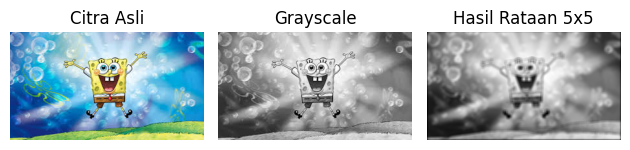

In [45]:
# subplot 1: citra asli (RGB)
plt.subplot(1, 3, 1)
plt.imshow(img_color)           # otomatis menampilkan berwarna
plt.title("Citra Asli")
plt.axis("off")

# subplot 2: citra grayscale
plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap="gray")   # pakai colormap gray
plt.title("Grayscale")
plt.axis("off")

# subplot 3: hasil konvolusi rataan 5x5
plt.subplot(1, 3, 3)
plt.imshow(img_result, cmap="gray")
plt.title("Hasil Rataan 5x5")
plt.axis("off")

plt.tight_layout()
plt.show()